A_K = 1.75
A_K = 0.00
PaA extinction:3.148744691230268,  BrA extinction:0.9109481324195402 (For A_K = 2.5 mag)
-0.10284283574807479


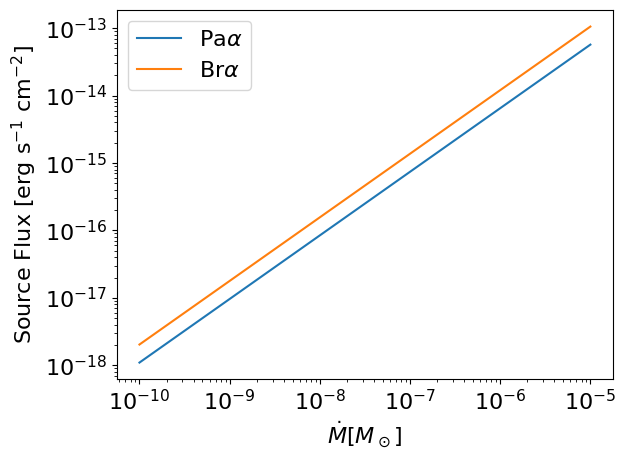

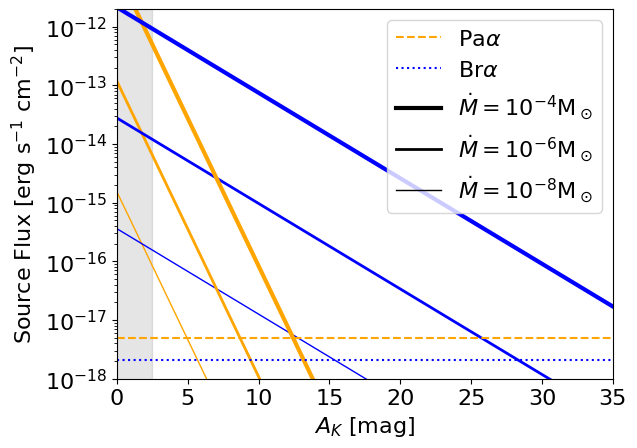

A_K=0 PaA: 1.5e-15 erg / (s cm2); BrA: 3.6e-16 erg / (s cm2)
A_K=2.5 PaA: 8.4e-17 erg / (s cm2); BrA: 1.6e-16 erg / (s cm2)
A_K=4 PaA: 1.5e-17 erg / (s cm2); BrA: 9.4e-17 erg / (s cm2)
A_K=5 PaA: 4.6e-18 erg / (s cm2); BrA: 6.7e-17 erg / (s cm2)
A_K=7.5 PaA: 2.6e-19 erg / (s cm2); BrA: 2.9e-17 erg / (s cm2)
A_K=10 PaA: 1.4e-20 erg / (s cm2); BrA: 1.3e-17 erg / (s cm2)


In [3]:
import numpy as np
from astropy import units as u
from astropy import constants
from sensitivity import cardelli_law
from pyspeckit.spectrum.models import hydrogen
from hii_sensitivity import ha_to_hb_1e4, paa_to_hb_1e4, bra_to_hgamma_1e4, pab_to_hgamma_1e4, hg_to_hb_1e4, wl_paa
from astroquery.svo_fps import SvoFps

wl_bra = hydrogen.wavelength['bracketta']*u.um
twomass = SvoFps.get_filter_list('2MASS')
wl_Ks = twomass[twomass['filterID'].astype(str)=='2MASS/2MASS.Ks']['WavelengthCen'][0] * u.AA

def lacc(mdot, rstar=u.R_sun, mstar=u.M_sun):
    # Alcala+ 2017 eqn 1
    # 1.25 comes from assuming r_inner disk = 5 r_star
    return (mdot / 1.25 * constants.G * mstar / rstar).to(u.L_sun)

def log_pab(lacc):
    # from table B1 of Alcala+2017:
    # log L_acc = 1.06 log L_pab + 2.76
    # so
    # log L_pab = (log L_acc - 2.76) / 1.06
    return 1/1.06 * np.log10(lacc/u.L_sun) - 2.76/1.06

def log_paa(lacc):
    # pab * (paa / hb) * (hb / hg) *  (hg / pab)
    return log_pab(lacc) + np.log10(paa_to_hb_1e4 / hg_to_hb_1e4 / pab_to_hgamma_1e4)

def log_bra(lacc):
    # brackett alpha prediction from PaB (could use BrG too...)
    return log_pab(lacc) + np.log10(bra_to_hgamma_1e4 / pab_to_hgamma_1e4)

def L_paa(lacc):
    return 10**log_paa(lacc) * u.L_sun

def L_bra(lacc):
    return 10**log_bra(lacc) * u.L_sun

def S_paa(lacc, distance=5.4*u.kpc, A_K=0):
    A_paa = (cardelli_law(wl_paa) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_paa / 2.5)
    return (L_paa(lacc) / (4*np.pi*distance**2)).to(u.erg/u.s/u.cm**2) * attenuation

def S_bra(lacc, distance=5.4*u.kpc, A_K=0):
    A_bra = (cardelli_law(wl_bra) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_bra / 2.5)
    return (L_bra(lacc) / (4*np.pi*distance**2)).to(u.erg/u.s/u.cm**2) * attenuation

def extinction_of_lineratio(observed_lineratio):
    paa_to_bra = paa_to_hb_1e4 / hg_to_hb_1e4 / bra_to_hgamma_1e4
    """
    observed = F_paa / F_bra = F_int,paa atten_paa / (F_int,bra atten_bra)
    intrinsic = F_int,paa / F_int,bra
    atten = 10^-(A/2.5)
    observed = 10^(-a_paa / 2.5) / 10^(-a_bra / 2.5) * intrinsic
    observed / intrinsic = 10^(-(a_paa - a bra) / 2.5)
    log( observed / intrinsic ) = -(a_paa - a_bra) / 2.5
    """
    delta_A = -2.5 * np.log10(observed_lineratio / paa_to_bra)
    """
    a_paa = ccm(1.87) / ccm(2.16) * A_K
    a_pbra = ccm(4.05) / ccm(2.16) * A_K
    a_paa - a_bra = (ccm(1.87) - ccm(4.05)) / ccm(2.16) * A_K
    A_K = (a_paa - a_bra) * ccm(2.16) / (ccm(1.87) - ccm(4.05))
    A_K = delta_A * ccm(2.16) / (ccm(1.87) - ccm(4.05))
    """
    A_K = delta_A * cardelli_law(wl_Ks) / (cardelli_law(wl_paa) - cardelli_law(wl_bra))
    return A_K

#if __name__ == "__main__":

    # Ekstrom 2012 evolutionary models; we'll use the age=10^6.5 for zero-age radii, lums

from astropy import visualization
visualization.quantity_support()
import pylab as pl
pl.ion()
#from astroquery.vizier import Vizier
#tbl = Vizier(row_limit=1e7, columns=['**']).get_catalogs('J/A+A/537/A146/iso')[0]

print(f"A_K = {extinction_of_lineratio(1):0.2f}")
print(f"A_K = {extinction_of_lineratio(4.23):0.2f}")

jwst_paa_tr = SvoFps.get_transmission_data('JWST/NIRCam.F187N')
jwst_paa_effectivewidth = (np.diff(jwst_paa_tr['Wavelength'].quantity) * jwst_paa_tr['Transmission'].quantity[1:]).sum() / jwst_paa_tr['Transmission'].quantity[1:].max()
jwst_paa_central_wavelength = (jwst_paa_tr['Wavelength'].quantity * jwst_paa_tr['Transmission'].quantity).sum() / jwst_paa_tr['Transmission'].quantity.sum()
jwst_paa_effectivewidth_hz = (jwst_paa_effectivewidth / jwst_paa_central_wavelength) * jwst_paa_central_wavelength.to(u.Hz, u.spectral())

jwst_bra_tr = SvoFps.get_transmission_data('JWST/NIRCam.F405N')
jwst_bra_effectivewidth = (np.diff(jwst_bra_tr['Wavelength'].quantity) * jwst_bra_tr['Transmission'].quantity[1:]).sum() / jwst_bra_tr['Transmission'].quantity[1:].max()
jwst_bra_central_wavelength = (jwst_bra_tr['Wavelength'].quantity * jwst_bra_tr['Transmission'].quantity).sum() / jwst_bra_tr['Transmission'].quantity.sum()
jwst_bra_effectivewidth_hz = (jwst_bra_effectivewidth / jwst_bra_central_wavelength) * jwst_bra_central_wavelength.to(u.Hz, u.spectral())


pl.figure(1)
pl.clf()
mdot = np.logspace(-10, -5)*u.M_sun/u.yr
lacc_vals = lacc(mdot)
spaa = S_paa(lacc_vals, distance=5.4*u.kpc)
sbra = S_bra(lacc_vals, distance=5.4*u.kpc)

# values computed for 24 exposures RAPID 2 group
limit_10sigma_paa = 2.7e-17 * u.erg/u.s/u.cm**2
limit_10sigma_bra = 4.25e-17 * u.erg/u.s/u.cm**2

# values computed for 24 exposures MEDIUM2 4-group
limit_10sigma_paa = 5e-18 * u.erg/u.s/u.cm**2
limit_10sigma_bra = 2.1e-18 * u.erg/u.s/u.cm**2

A_K = 2.5
A_paa = (cardelli_law(wl_paa) / cardelli_law(wl_Ks)) * A_K
A_bra = (cardelli_law(wl_bra) / cardelli_law(wl_Ks)) * A_K
print(f"PaA extinction:{A_paa},  BrA extinction:{A_bra} (For A_K = 2.5 mag)")

# mJy if we want to include it in the filters
spaa_mJy = (spaa / jwst_paa_effectivewidth_hz).to(u.mJy)
sbra_mJy = (sbra / jwst_paa_effectivewidth_hz).to(u.mJy)

pl.loglog(mdot, spaa * 10**(-A_paa/2.5), label='Pa$\\alpha$')
pl.loglog(mdot, sbra * 10**(-A_bra/2.5), label='Br$\\alpha$')

pl.xlabel(f'$\\dot{{M}} [M_\odot]$')
pl.ylabel("Source Flux [erg s$^{-1}$ cm$^{-2}$]")
pl.legend(loc='best')

#mag_paa_brighter = 2.5*np.log10(ha_to_paa_1e4_phots) / (cardelli_law(wl_halpha) - cardelli_law(wl_paa))
#print(f"Magnitude at which PaA is brighter than H-alpha is {mag_paa_brighter}")


print(cardelli_law(wl_bra) - cardelli_law(wl_paa))


pl.figure(2)
pl.clf()
ax = pl.gca()

A_Ks = np.linspace(0, 40, 100)
for mdot,lw in zip((1e-8, 1e-6, 1e-4)*u.M_sun/u.yr, (1,2,3)):
    line, = pl.semilogy(A_Ks, S_paa(lacc(mdot), distance=5.4*u.kpc, A_K=A_Ks), linewidth=lw, color='orange')#label='Pa$\\alpha$')
    line, = pl.semilogy(A_Ks, S_bra(lacc(mdot), distance=5.4*u.kpc, A_K=A_Ks), linewidth=lw, color='blue')#label='Br$\\alpha$')
# ann = ax.annotate("$\dot{M}=10^{-8}~\mathrm{M}_\odot\mathrm{yr}^{-1}$", (2.1, 5e-17, ), rotation=-8)
# ann.set_bbox(dict(facecolor='white', alpha=0.8, edgecolor='white'))
# ann = ax.annotate("$\dot{M}=10^{-6}~\mathrm{M}_\odot\mathrm{yr}^{-1}$", (2.1, 5e-15, ), rotation=-7)
# ann.set_bbox(dict(facecolor='white', alpha=0.8, edgecolor='white'))
# ann = ax.annotate("$\dot{M}=10^{-4}~\mathrm{M}_\odot\mathrm{yr}^{-1}$", (2.1, 5e-13, ), rotation=0)
# ann.set_bbox(dict(facecolor='white', alpha=0.8, edgecolor='white'))


pl.axhline(limit_10sigma_paa, linestyle='--', color='orange', label='Pa$\\alpha$')
pl.axhline(limit_10sigma_bra, linestyle=':', color='blue', label='Br$\\alpha$')
pl.fill_betweenx(ax.get_ylim(), 0, 2.5, color='k', alpha=0.1)

ax.plot([], [], color='k', lw=3, label=r'$\dot{M}=10^{-4}\mathrm{M}_\odot$')
ax.plot([], [], color='k', lw=2, label=r'$\dot{M}=10^{-6}\mathrm{M}_\odot$')
ax.plot([], [], color='k', lw=1, label=r'$\dot{M}=10^{-8}\mathrm{M}_\odot$')

ax.set_ylim(1e-18, 2e-12)
ax.set_xlim(0, 35)

pl.xlabel('$A_K$ [mag]')
pl.ylabel("Source Flux [erg s$^{-1}$ cm$^{-2}$]")
pl.legend(loc='best')
#pl.savefig("accretion_sensitivity_PaA_BrA.png", bbox_inches='tight')
#pl.savefig("accretion_sensitivity_PaA_BrA.pdf", bbox_inches='tight')
pl.show()

for A_K in (0, 2.5, 4, 5, 7.5, 10):
    print(f'A_K={A_K} PaA: {S_paa(lacc(1e-8*u.M_sun/u.yr), distance=5.4*u.kpc, A_K=A_K):0.2g}; BrA: {S_bra(lacc(1e-8*u.M_sun/u.yr), distance=5.4*u.kpc, A_K=A_K):0.2g}')